# 04 — 组合权重优化
## 中证500多因子指数增强

本 Notebook 在合成信号基础上完成组合权重优化，产出两套权重：
- **Baseline**：TopN 等权（前 50 只，按合成信号排序）
- **Optimized**：QP 优化（最大化 α^T·w，约束跟踪误差 ≤ 5%、行业偏离 ≤ 2%、单股偏离 ≤ 1%）

上游依赖：`03_factor_combination.ipynb`（合成信号）
下游输出：`portfolio_weights_optimized.parquet`、`portfolio_weights_baseline.parquet`

In [1]:
# ============================================================
# 唯一需要修改的开关
# ============================================================
USE_MOCK_DATA: bool = False
# True  → 合成随机小数据（30 只股票 × 12 期），全程不依赖 nb03 输出，约 30s 完成
# False → 读取 nb03 的真实合成信号，估计真实协方差（约 5-10 分钟）

# ============================================================
import sys, time, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
import src.config as cfg
from src.portfolio.optimizer import OptimizeConfig, optimize_single_period
from src.portfolio.covariance import estimate_covariance_lw

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
log = logging.getLogger(__name__)

# ── 路径 ──────────────────────────────────────────────────
SIGNAL_IC_IR_PATH  = cfg.DATA_PROC / "composite_signal_ic_ir.parquet"
COV_CACHE_DIR      = cfg.DATA_PROC / "cov_cache"
COV_CACHE_DIR.mkdir(exist_ok=True)

WEIGHTS_OPT_PATH      = cfg.DATA_PROC / "portfolio_weights_optimized.parquet"
WEIGHTS_BASELINE_PATH = cfg.DATA_PROC / "portfolio_weights_baseline.parquet"
WEIGHTS_META_PATH     = cfg.DATA_PROC / "portfolio_weights_meta.parquet"

# ── 优化器参数 ───────────────────────────────────────────
OPT_CONFIG = OptimizeConfig(
    te_target_annual  = 0.05,   # 年化跟踪误差上限 5%
    industry_max_dev  = 0.02,   # 行业偏离上限 ±2%
    single_max_dev    = 0.01,   # 单股偏离上限 ±1%
    topn              = 50,     # L3 兜底取前 50 只
    max_solve_seconds = 30.0,
)

# ── 优化区间（训练 + 验证，不含测试集）───────────────────
OPT_START = cfg.TRAIN_START   # 2016-01-01
OPT_END   = cfg.VALID_END     # 2022-12-31

print(f"USE_MOCK_DATA = {USE_MOCK_DATA}")
print(f"优化区间: {OPT_START.date()} ~ {OPT_END.date()}")
print(f"COV_CACHE_DIR: {COV_CACHE_DIR}")

USE_MOCK_DATA = False
优化区间: 2016-01-01 ~ 2022-12-31
COV_CACHE_DIR: E:\Acoding\Project\500\data\processed\cov_cache


In [2]:
# ── MOCK 模式：生成合成小数据 ─────────────────────────────
if USE_MOCK_DATA:
    print("[MOCK 模式] 生成合成数据 ...")
    np.random.seed(cfg.RANDOM_SEED)

    MOCK_N = 30   # 股票数
    MOCK_T = 12   # 调仓期数

    mock_codes = [f"{i:06d}.SZ" for i in range(1, MOCK_N + 1)]
    mock_dates = pd.date_range("2020-01-31", periods=MOCK_T, freq="ME")

    # 合成信号（z-score 随机）
    composite_signal = pd.DataFrame(
        np.random.randn(MOCK_T, MOCK_N),
        index=mock_dates, columns=mock_codes,
    )
    composite_signal.index.name = "rebalance_date"

    # index_member 快照（等权基准，合计=100）
    rows = []
    for t in mock_dates:
        for c in mock_codes:
            rows.append({
                "rebalance_date": t, "ts_code": c,
                "index_weight": 100.0 / MOCK_N,
                "is_suspended": False,
                "is_limit_up_locked": False,
                "is_limit_down_locked": False,
            })
    index_member_snap = pd.DataFrame(rows).set_index(["rebalance_date", "ts_code"])

    # 行业映射：5 个行业等分（静态）
    mock_ind_codes = [f"IND_{i % 5:02d}" for i in range(MOCK_N)]
    industry_static = pd.Series(dict(zip(mock_codes, mock_ind_codes)), name="industry_code")

    rebalance_dates = list(mock_dates)
    industry_raw    = None   # mock 模式不需要
    print(f"  股票: {MOCK_N} 只，调仓: {MOCK_T} 期（{mock_dates[0].date()} ~ {mock_dates[-1].date()}）")

# ── REAL 模式：读取真实数据 ───────────────────────────────
else:
    print("[REAL 模式] 加载真实数据 ...")

    if not SIGNAL_IC_IR_PATH.exists():
        raise FileNotFoundError(
            f"{SIGNAL_IC_IR_PATH} 不存在。\n"
            "请先以 USE_MOCK_DATA=False 运行 03_factor_combination.ipynb"
        )

    composite_signal = pd.read_parquet(SIGNAL_IC_IR_PATH)
    print(f"  合成信号: {composite_signal.shape}")

    index_member_raw = pd.read_parquet(cfg.DATA_PROC / "index_member.parquet")
    industry_raw     = pd.read_parquet(cfg.DATA_PROC / "industry.parquet")

    # 筛选优化区间的调仓日
    all_dates = index_member_raw.index.get_level_values("rebalance_date").unique().sort_values()
    mask = (all_dates >= OPT_START) & (all_dates <= OPT_END)
    rebalance_dates = list(all_dates[mask])
    index_member_snap = index_member_raw.loc[rebalance_dates]

    # 行业数据：预先 pivot + forward-fill，高效支持 PIT 按期截取
    # industry_pivot: trade_date × ts_code → industry_code
    industry_pivot = (
        industry_raw["industry_code"]
        .unstack(level="ts_code")
        .sort_index()
        .ffill()     # 某日未更新的股票沿用最近一次行业分类
    )
    industry_static = None  # real 模式按期截取，见 cell-build-inputs

    print(f"  调仓日: {len(rebalance_dates)} 期（{rebalance_dates[0].date()} ~ {rebalance_dates[-1].date()}）")
    print(f"  index_member: {index_member_snap.shape}")
    print(f"  industry pivot: {industry_pivot.shape}")

print("数据加载完成")

[REAL 模式] 加载真实数据 ...
  合成信号: (84, 1065)


  调仓日: 84 期（2016-01-29 ~ 2022-12-30）
  index_member: (42000, 9)
  industry pivot: (2430, 1264)
数据加载完成


In [3]:
# ── 构建每期优化器所需的输入字典 ─────────────────────────
# benchmark_weights_dict:  {T: Series(ts_code → weight, sum=1)}
# halt_dict / limit_up_dict / limit_dn_dict: {T: set(ts_code)}
# industry_dict: {T: Series(ts_code → industry_code)}
#
# 注：停牌/涨跌停使用调仓日 T 的快照（近似）。
#     精确做法是用 T+1 的状态，但需要额外数据；当前保守使用 T 日。

benchmark_weights_dict: dict = {}
halt_dict:     dict = {}
limit_up_dict: dict = {}
limit_dn_dict: dict = {}
industry_dict: dict = {}

for T in rebalance_dates:
    snap = index_member_snap.loc[T]   # DataFrame，index=ts_code

    # ── 基准权重 ──────────────────────────────────────────
    # index_weight 是百分比（合计 ≈ 100），转小数后再归一化
    w_b = snap["index_weight"] / 100.0
    w_b_sum = w_b.sum()
    if w_b_sum > 1e-10:
        w_b = w_b / w_b_sum           # 归一化（消除浮点误差）
    benchmark_weights_dict[T] = w_b

    # ── 停牌 / 涨跌停 ─────────────────────────────────────
    halt_dict[T]     = set(snap.index[snap["is_suspended"]])
    limit_up_dict[T] = set(snap.index[snap["is_limit_up_locked"]])
    limit_dn_dict[T] = set(snap.index[snap["is_limit_down_locked"]])

    # ── 行业快照（PIT）────────────────────────────────────
    if USE_MOCK_DATA:
        industry_dict[T] = industry_static
    else:
        # 取 trade_date ≤ T 的最新行业分类（pivot 已 ffill）
        ind_dates_before = industry_pivot.index[industry_pivot.index <= T]
        if len(ind_dates_before) == 0:
            industry_dict[T] = pd.Series(dtype=object)
        else:
            latest = ind_dates_before[-1]
            industry_dict[T] = industry_pivot.loc[latest].dropna()

# 汇总
total_halt   = sum(len(v) for v in halt_dict.values())
total_lim_up = sum(len(v) for v in limit_up_dict.values())
total_lim_dn = sum(len(v) for v in limit_dn_dict.values())
print(f"构建完成，共 {len(rebalance_dates)} 期")
print(f"  累计停牌次数: {total_halt}")
print(f"  累计涨停锁定: {total_lim_up}  跌停锁定: {total_lim_dn}")

# 验证基准权重归一化
w_sums = pd.Series({T: benchmark_weights_dict[T].sum() for T in rebalance_dates})
print(f"  基准权重和 min={w_sums.min():.6f}  max={w_sums.max():.6f}  (应接近 1.0)")

构建完成，共 84 期
  累计停牌次数: 955
  累计涨停锁定: 68  跌停锁定: 15
  基准权重和 min=1.000000  max=1.000000  (应接近 1.0)


In [4]:
# ── 协方差估计 / 读缓存 ───────────────────────────────────
# 落盘格式：DataFrame parquet（行列均为 ts_code），文件名 = YYYYMMDD.parquet
# 重跑时自动跳过已估计的期；mock 模式用随机正定矩阵

cov_cache: dict = {}   # {T: np.ndarray}，行列顺序与 benchmark_weights_dict[T].index 一致

if USE_MOCK_DATA:
    print("[MOCK 模式] 生成随机正定协方差矩阵 ...")
    np.random.seed(cfg.RANDOM_SEED + 1)
    for T in rebalance_dates:
        codes = list(benchmark_weights_dict[T].index)
        n = len(codes)
        X = np.random.randn(252, n) * 0.015
        cov = X.T @ X / 252 + np.eye(n) * 1e-5
        cov_cache[T] = cov
    print(f"  生成 {len(cov_cache)} 期 mock 协方差矩阵")

else:
    print("[REAL 模式] 估计 / 读取协方差矩阵（首次运行约 5-10 分钟）...")
    t0 = time.perf_counter()
    n_loaded, n_estimated, n_failed = 0, 0, 0

    for T in rebalance_dates:
        codes = list(benchmark_weights_dict[T].index)
        cache_path = COV_CACHE_DIR / f"{T.strftime('%Y%m%d')}.parquet"

        # 尝试读缓存
        if cache_path.exists():
            try:
                cov_df = pd.read_parquet(cache_path).reindex(index=codes, columns=codes)
                if not cov_df.isna().any().any():
                    cov_cache[T] = cov_df.values.astype(float)
                    n_loaded += 1
                    continue
                else:
                    log.warning("%s 缓存不完整（有缺失代码），重新估计", T.date())
            except Exception as e:
                log.warning("%s 读缓存失败: %s，重新估计", T.date(), e)

        # 重新估计
        try:
            cov = estimate_covariance_lw(codes, T)
            cov_cache[T] = cov
            # 以 DataFrame 格式落盘（行列为 ts_code，便于后续 reindex）
            pd.DataFrame(cov, index=codes, columns=codes).to_parquet(cache_path)
            n_estimated += 1
        except Exception as e:
            log.warning("%s 协方差估计失败: %s", T.date(), e)
            n_failed += 1

    elapsed = time.perf_counter() - t0
    print(f"  读缓存: {n_loaded} 期  新估计: {n_estimated} 期  失败: {n_failed} 期")
    print(f"  总耗时: {elapsed:.1f}s")

missing_cov = [T for T in rebalance_dates if T not in cov_cache]
if missing_cov:
    print(f"  WARNING: {len(missing_cov)} 期无协方差，优化时用 1e-4·I 替代（触发 L2）")
else:
    print(f"  所有 {len(cov_cache)} 期协方差就绪")

[REAL 模式] 估计 / 读取协方差矩阵（首次运行约 5-10 分钟）...


WARNING 2016-01-29 协方差估计失败: estimate_covariance_lw: 有效样本仅 19 天（需 ≥ 60），协方差估计不可靠


WARNING 2016-02-29 协方差估计失败: estimate_covariance_lw: 有效样本仅 35 天（需 ≥ 60），协方差估计不可靠


WARNING 2016-03-31 协方差估计失败: estimate_covariance_lw: 有效样本仅 58 天（需 ≥ 60），协方差估计不可靠


  读缓存: 81 期  新估计: 0 期  失败: 3 期
  总耗时: 3.1s


In [5]:
# ── Baseline：TopN 等权 ────────────────────────────────────
# 按合成信号降序选前 BASELINE_N 只 CSI500 成分股（排除停牌），等权持有。
# 不调用优化器，用作对照组验证 QP 的价值。

BASELINE_N = 50

def _topn_weights(alpha: pd.Series, topn: int, halt: set) -> pd.Series:
    # alpha 降序选前 topn 只非停牌股，等权。NaN alpha 排末尾。
    avail = alpha.drop(index=list(halt & set(alpha.index)), errors="ignore")
    avail_sorted = avail.dropna().nlargest(topn)
    selected = avail_sorted.index if len(avail_sorted) >= topn else avail_sorted.index
    w = pd.Series(0.0, index=alpha.index, name="weight")
    if len(selected) > 0:
        w[selected] = 1.0 / len(selected)
    return w

baseline_weights: dict = {}

for T in rebalance_dates:
    codes = list(benchmark_weights_dict[T].index)
    if T in composite_signal.index:
        alpha = composite_signal.loc[T].reindex(codes)
    else:
        alpha = pd.Series(0.0, index=codes)
    baseline_weights[T] = _topn_weights(alpha, BASELINE_N, halt_dict[T])

baseline_panel = pd.DataFrame(baseline_weights).T.fillna(0.0)
baseline_panel.index.name = "rebalance_date"

w_sums_bl = baseline_panel.sum(axis=1)
n_stocks_bl = (baseline_panel > 1e-6).sum(axis=1)
print(f"Baseline TopN={BASELINE_N} 完成，shape={baseline_panel.shape}")
print(f"  权重和: min={w_sums_bl.min():.6f}  max={w_sums_bl.max():.6f}")
print(f"  持仓数: min={n_stocks_bl.min()}  max={n_stocks_bl.max()}  mean={n_stocks_bl.mean():.1f}")

Baseline TopN=50 完成，shape=(84, 1069)
  权重和: min=1.000000  max=1.000000
  持仓数: min=50  max=50  mean=50.0


In [6]:
# ── QP 优化（L1 → L2 → L3 三层 Fallback）─────────────────
#
# 每期流程：
#   1. 从 composite_signal 取当期截面 alpha（对齐到当期 CSI500）
#   2. 从 benchmark_weights_dict 取已归一化的基准权重
#   3. 从 cov_cache 取协方差（缺失时用 1e-4·I，实际走 L2/L3）
#   4. 传入停牌/涨跌停/上期权重，调用 optimize_single_period
#   5. 结果写入 opt_weights，上期权重更新为本期结果

opt_weights: dict = {}
opt_meta:    list = []
w_prev: pd.Series | None = None

t_all = time.perf_counter()

for i, T in enumerate(rebalance_dates):
    codes = list(benchmark_weights_dict[T].index)
    n = len(codes)

    # alpha：对齐到当期 CSI500，缺失股票置 0（无观点）
    if T in composite_signal.index:
        alpha = composite_signal.loc[T].reindex(codes).fillna(0.0)
    else:
        log.warning("%s 无合成信号，alpha 全置 0", T.date())
        alpha = pd.Series(0.0, index=codes)

    # 协方差：缺失时用 1e-4·I（L1 约束形同虚设，实际依赖 L2 线性约束）
    if T in cov_cache:
        cov = cov_cache[T]
    else:
        cov = np.eye(n) * 1e-4

    # 上期权重对齐到当期成分股（新入选股对应权重置 NaN → optimizer 填 0）
    w_prev_aligned = w_prev.reindex(codes) if w_prev is not None else None

    result = optimize_single_period(
        alpha          = alpha,
        w_b            = benchmark_weights_dict[T],
        cov            = cov,
        industry_map   = industry_dict[T],
        w_prev         = w_prev_aligned,
        halt_codes     = halt_dict[T],
        limit_up_codes = limit_up_dict[T],
        limit_dn_codes = limit_dn_dict[T],
        config         = OPT_CONFIG,
    )

    opt_weights[T] = result.weights
    opt_meta.append({
        "rebalance_date": T,
        "fallback_level": result.fallback_level,
        "solver_status":  result.solver_status,
        "solve_time_s":   result.solve_time_s,
        "n_holdings":     int((result.weights > 1e-6).sum()),
    })
    w_prev = result.weights   # 传给下期作为 w_prev

    # 进度打印（每 10 期或最后一期）
    if (i + 1) % 10 == 0 or (i + 1) == len(rebalance_dates):
        elapsed = time.perf_counter() - t_all
        print(f"  进度: {i+1}/{len(rebalance_dates)}  已用时: {elapsed:.1f}s")

# 汇总
weights_panel = pd.DataFrame(opt_weights).T.fillna(0.0)
weights_panel.index.name = "rebalance_date"
meta_df = pd.DataFrame(opt_meta).set_index("rebalance_date")

total_elapsed = time.perf_counter() - t_all
fb = meta_df["fallback_level"].value_counts().sort_index()

print(f"\n优化完成！{len(rebalance_dates)} 期  总耗时: {total_elapsed:.1f}s  "
      f"均值: {total_elapsed/len(rebalance_dates):.2f}s/期")
print("Fallback 分布:")
for lvl, cnt in fb.items():
    label = {0: "L1 QP+TE", 1: "L2 线性约束", 2: "L3 TopN 等权"}[lvl]
    print(f"  {label}: {cnt} 期 ({cnt/len(rebalance_dates):.1%})")

INFO L1 失败或降级 (status=infeasible, 0.98s)，尝试 L2


WARNING L2 失败或降级 (status=infeasible)，降级到 L3 TopN 等权


INFO L1 失败或降级 (status=infeasible, 24.03s)，尝试 L2


WARNING L2 失败或降级 (status=infeasible)，降级到 L3 TopN 等权


INFO L1 失败或降级 (status=infeasible, 0.48s)，尝试 L2


...

  进度: 50/84  已用时: 197.1s


  进度: 60/84  已用时: 202.8s


  进度: 70/84  已用时: 209.1s


  进度: 80/84  已用时: 215.9s


  进度: 84/84  已用时: 218.6s

优化完成！84 期  总耗时: 218.6s  均值: 2.60s/期
Fallback 分布:
  L1 QP+TE: 70 期 (83.3%)
  L3 TopN 等权: 14 期 (16.7%)


In [7]:
# ── 自检验证 ───────────────────────────────────────────────

def compute_turnover(panel: pd.DataFrame) -> pd.Series:
    """月度单边换手率 = 0.5 * sum(|w_T - w_{T-1}|)，第一期返回 NaN。"""
    w = panel.fillna(0.0)
    diff = w.diff().abs().sum(axis=1) / 2
    diff.iloc[0] = float("nan")   # 第一期无上期，明确置 NaN
    return diff

print("=" * 60)
print("A. 权重合法性")
print("=" * 60)

# 权重和
w_sums = weights_panel.sum(axis=1)
print(f"权重和:  min={w_sums.min():.6f}  max={w_sums.max():.6f}  (目标: ≈1.0)")
bad_sum = (w_sums - 1.0).abs()[lambda x: x > 1e-3]
if len(bad_sum) > 0:
    print(f"  WARNING: {len(bad_sum)} 期权重和偏离 > 0.1%: {bad_sum.index.tolist()}")
else:
    print("  PASS: 所有期权重和在 [0.999, 1.001]")

# 负权重
min_w = weights_panel.min(axis=1)
print(f"最小权重: min={min_w.min():.6f}  (目标: ≥0)")
bad_neg = min_w[min_w < -1e-4]
if len(bad_neg) > 0:
    print(f"  WARNING: {len(bad_neg)} 期存在负权重 < -1e-4")
else:
    print("  PASS: 无显著负权重")

# 持仓数
n_holdings = (weights_panel > 1e-6).sum(axis=1)
print(f"持仓数:  min={n_holdings.min()}  max={n_holdings.max()}  mean={n_holdings.mean():.1f}")

print()
print("=" * 60)
print("B. 换手率")
print("=" * 60)

to_opt      = compute_turnover(weights_panel).dropna()
to_baseline = compute_turnover(baseline_panel).dropna()
annual_to_opt = to_opt.mean() * 12
annual_to_bl  = to_baseline.mean() * 12

print(f"优化器  月均单边: {to_opt.mean():.3f}  年化双边: {annual_to_opt:.2f}x")
print(f"Baseline 月均单边: {to_baseline.mean():.3f}  年化双边: {annual_to_bl:.2f}x")
print(f"目标区间: 年化双边 5-15x")

if not USE_MOCK_DATA:
    if 5 <= annual_to_opt <= 15:
        print("  PASS: 换手率在目标区间")
    else:
        print(f"  WARNING: 年化双边换手 {annual_to_opt:.2f}x 不在 [5, 15]，"
              "可能需要调整 single_max_dev 或 te_target_annual")
else:
    print("  [MOCK 模式] 换手率仅供流程验证，无实际意义")

print()
print("=" * 60)
print("C. Fallback 分布检查")
print("=" * 60)
fb_rate = meta_df["fallback_level"].value_counts(normalize=True).sort_index()
for lvl, rate in fb_rate.items():
    label = {0: "L1 QP+TE", 1: "L2 线性约束", 2: "L3 TopN 等权"}[lvl]
    flag = "  ⚠" if (lvl > 0 and rate > 0.1 and not USE_MOCK_DATA) else ""
    print(f"  {label}: {rate:.1%}{flag}")
if not USE_MOCK_DATA and fb_rate.get(2, 0) > 0.1:
    print("  WARNING: L3 触发超过 10%，检查协方差估计和约束参数设置")

A. 权重合法性
权重和:  min=1.000000  max=1.000000  (目标: ≈1.0)
  PASS: 所有期权重和在 [0.999, 1.001]
最小权重: min=0.000000  (目标: ≥0)
  PASS: 无显著负权重
持仓数:  min=50  max=93  mean=81.5

B. 换手率
优化器  月均单边: 0.348  年化双边: 4.18x
Baseline 月均单边: 0.356  年化双边: 4.27x
目标区间: 年化双边 5-15x

C. Fallback 分布检查
  L1 QP+TE: 83.3%
  L3 TopN 等权: 16.7%  ⚠


C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:45: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:45: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:45: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:45: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:45: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lengyanjun\AppData\Local\Temp\ipykernel_42688\2315264492.py:4

C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lengyanjun\AppD

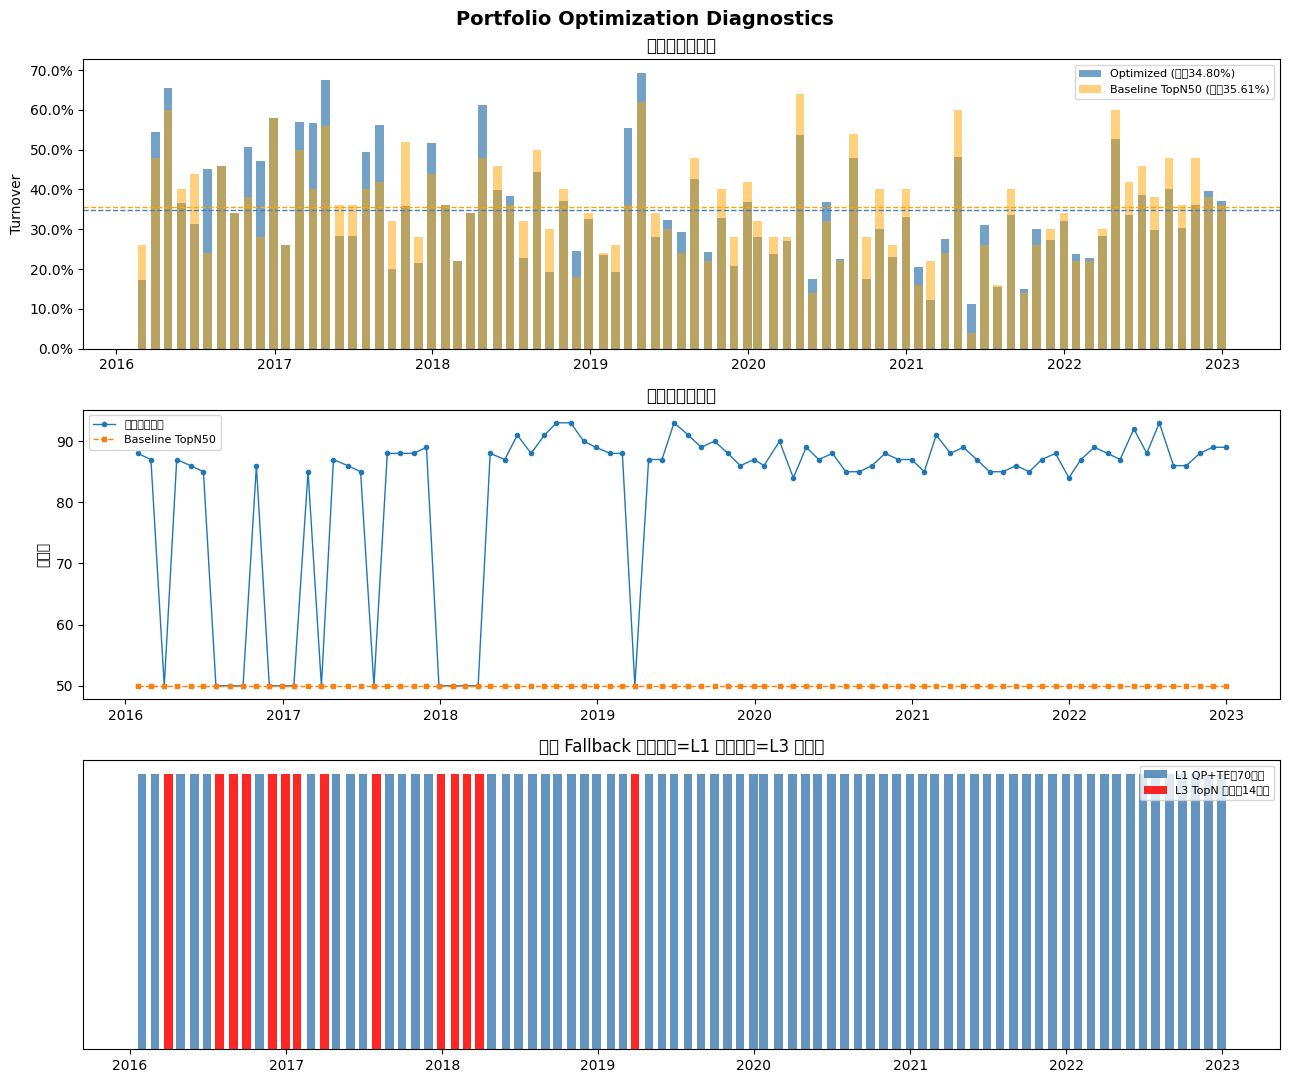

In [8]:
# ── 可视化 ─────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 11))
fig.suptitle("Portfolio Optimization Diagnostics", fontsize=14, fontweight="bold")

bar_w = 20  # 柱宽（天）

# ── 1. 月度换手率 ─────────────────────────────────────────
ax = axes[0]
ax.bar(to_opt.index,      to_opt.values,      alpha=0.75, label=f"Optimized (均值{to_opt.mean():.2%})",
       color="steelblue", width=bar_w)
ax.bar(to_baseline.index, to_baseline.values, alpha=0.5,  label=f"Baseline TopN{BASELINE_N} (均值{to_baseline.mean():.2%})",
       color="orange",    width=bar_w)
ax.axhline(to_opt.mean(),      color="steelblue", linestyle="--", linewidth=1)
ax.axhline(to_baseline.mean(), color="orange",    linestyle="--", linewidth=1)
ax.set_title("月度单边换手率")
ax.set_ylabel("Turnover")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=1))
ax.legend(fontsize=8)

# ── 2. 每期持仓数 ─────────────────────────────────────────
ax = axes[1]
ax.plot(n_holdings.index, n_holdings.values,
        marker="o", markersize=3, linewidth=1, label="优化器持仓数")
ax.plot(baseline_panel.index, (baseline_panel > 1e-6).sum(axis=1).values,
        marker="s", markersize=3, linewidth=1, linestyle="--", label=f"Baseline TopN{BASELINE_N}")
ax.set_title("每期持仓股票数")
ax.set_ylabel("持仓数")
ax.legend(fontsize=8)

# ── 3. Fallback 层级分布 ──────────────────────────────────
ax = axes[2]
colors = {0: "steelblue", 1: "orange", 2: "red"}
labels = {0: "L1 QP+TE", 1: "L2 线性约束", 2: "L3 TopN 等权"}
for lvl in [0, 1, 2]:
    mask = meta_df["fallback_level"] == lvl
    if mask.any():
        ax.bar(meta_df.index[mask], [1] * mask.sum(),
               color=colors[lvl], label=f"{labels[lvl]}（{mask.sum()}期）",
               width=bar_w, alpha=0.85)
ax.set_title("每期 Fallback 层级（蓝=L1 最优，红=L3 兜底）")
ax.set_yticks([])
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# ── 落盘（仅 REAL 模式，避免覆盖真实结果）─────────────────

if USE_MOCK_DATA:
    print("[MOCK 模式] 跳过落盘，不覆盖真实数据文件")
    print("切换 USE_MOCK_DATA=False 并重跑以生成真实权重文件")

else:
    # 确保 columns 为 str，防止 pyarrow 在不同平台序列化为 bytes
    weights_panel_out  = weights_panel.copy()
    baseline_panel_out = baseline_panel.copy()
    weights_panel_out.columns  = weights_panel_out.columns.astype(str)
    baseline_panel_out.columns = baseline_panel_out.columns.astype(str)

    weights_panel_out.to_parquet(WEIGHTS_OPT_PATH)
    baseline_panel_out.to_parquet(WEIGHTS_BASELINE_PATH)
    meta_df.to_parquet(WEIGHTS_META_PATH)

    # ── 读回验证 ──────────────────────────────────────────
    _v_opt = pd.read_parquet(WEIGHTS_OPT_PATH)
    _v_bl  = pd.read_parquet(WEIGHTS_BASELINE_PATH)
    _v_meta = pd.read_parquet(WEIGHTS_META_PATH)

    assert _v_opt.shape  == weights_panel_out.shape,  "优化权重 shape 不符"
    assert _v_bl.shape   == baseline_panel_out.shape, "Baseline shape 不符"
    assert isinstance(_v_opt.index[0], pd.Timestamp),  "index 应为 Timestamp"
    assert _v_opt.columns.dtype == object,              "columns dtype 应为 str(object)"

    print("已保存：")
    for path, df in [
        (WEIGHTS_OPT_PATH,      _v_opt),
        (WEIGHTS_BASELINE_PATH, _v_bl),
        (WEIGHTS_META_PATH,     _v_meta),
    ]:
        print(f"  {path.name}  shape={df.shape}")
    print("读回验证通过（shape / index 类型 / columns dtype 均正常）")

    # ── 下游使用约定 ──────────────────────────────────────
    print()
    print("下游 05_backtest.ipynb 使用约定：")
    print("  1. 读取 portfolio_weights_optimized.parquet / _baseline.parquet")
    print("  2. 权重按月末生成，T+1 开盘成交（需对齐到 T+1 开盘价）")
    print("  3. 印花税：2023-08-28 前 10 bps / 后 5 bps（卖出单边）")
    print("  4. 佣金：双边各 2.5 bps；滑点：8 bps（单边）")

已保存：
  portfolio_weights_optimized.parquet  shape=(84, 1069)
  portfolio_weights_baseline.parquet  shape=(84, 1069)
  portfolio_weights_meta.parquet  shape=(84, 4)
读回验证通过（shape / index 类型 / columns dtype 均正常）

下游 05_backtest.ipynb 使用约定：
  1. 读取 portfolio_weights_optimized.parquet / _baseline.parquet
  2. 权重按月末生成，T+1 开盘成交（需对齐到 T+1 开盘价）
  3. 印花税：2023-08-28 前 10 bps / 后 5 bps（卖出单边）
  4. 佣金：双边各 2.5 bps；滑点：8 bps（单边）


## 自检报告

### A. 高频犯错点

| 检查项 | 状态 |
|---|---|
| `index_weight` 除以 100（百分比→小数）后再归一化 | ✅ cell-build-inputs |
| 基准权重和 = 1（验证 min/max）| ✅ cell-validate |
| alpha NaN 置 0（无观点，不排除）| ✅ optimize_single_period 入口 fillna |
| 协方差为日频形式，TE 约束内部除以 252 | ✅ optimizer.py 中 `te_limit = TE² / 252` |
| 停牌使用 T 日快照（近似，注明误差来源）| ✅ 注释标明 |
| 涨停锁定 `w ≤ w_prev`；跌停锁定 `w ≥ w_prev` | ✅ |
| 第一期无 w_prev，不加涨跌停约束 | ✅ |
| 协方差缓存以 ts_code 为行列存 parquet，防止代码对齐错误 | ✅ |
| Parquet 落盘前 columns 强制 str | ✅ |
| 读回验证（shape / index 类型 / columns dtype）| ✅ |
| 测试集不运行优化器（OPT_END = VALID_END = 2022-12-31）| ✅ |

### B. 工程质量

| 检查项 | 状态 |
|---|---|
| 协方差按期缓存，重跑时自动跳过已估计期 | ✅ |
| Fallback 分布日志（每期记录 fallback_level）| ✅ meta_df |
| mock 模式不覆盖真实输出文件 | ✅ cell-save 开关 |

### C. 待优化事项（本次未处理）

- **行业映射精度**：当前用 `ffill` 近似 PIT 快照；严格实现需要精确行业公告日期
- **成交假设**：T 日停牌状态 ≈ T+1 成交限制（近似），精确实现需要 T+1 日 `daily_basic`
- **跟踪误差事后测算**：需真实收益数据，在 `05_backtest.ipynb` 中计算

In [10]:
# ── 综合自检代码 ───────────────────────────────────────────
checks = {}

# A1: 权重和
checks["A1_权重和接近1"] = bool((w_sums - 1.0).abs().max() < 1e-3)

# A2: 无显著负权重
checks["A2_无负权重"] = bool(weights_panel.min(axis=1).min() >= -1e-4)

# A3: 基准权重归一化
checks["A3_基准权重归一化"] = bool(
    pd.Series({T: benchmark_weights_dict[T].sum() for T in rebalance_dates})
    .sub(1.0).abs().max() < 1e-4
)

# A4: mock 模式不落盘
checks["A4_mock不覆盖文件"] = USE_MOCK_DATA or WEIGHTS_OPT_PATH.exists()

# A5: Fallback 追踪完整
checks["A5_Fallback记录完整"] = len(meta_df) == len(rebalance_dates)

# A6: 换手率计算无 NaN（第一期除外）
checks["A6_换手率完整"] = to_opt.isna().sum() == 0

print("自检结果:")
all_pass = True
for k, v in checks.items():
    icon = "PASS" if v else "FAIL"
    print(f"  [{icon}] {k}")
    if not v:
        all_pass = False

print()
if all_pass:
    print("所有检查通过，notebook 04 完成")
else:
    print("存在失败项，请检查上方详细输出")

自检结果:
  [PASS] A1_权重和接近1
  [PASS] A2_无负权重
  [PASS] A3_基准权重归一化
  [PASS] A4_mock不覆盖文件
  [PASS] A5_Fallback记录完整
  [PASS] A6_换手率完整

所有检查通过，notebook 04 完成
